In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import sensors
from scipy.linalg import expm, logm
from utils import *

# Test bearing sensor

In [2]:
# Generate a random attitude
qtrue = expq(0.5*np.random.randn(3))
print("True attitude:", qtrue)

True attitude: [-0.12986838 -0.66241982 -0.16622383  0.71882113]


In [3]:
body_vector = [1, 0, 0]
bias_vector = [0, 0, 0]
M = [[ 9.99999998e-01, -4.84790564e-05,  4.84837572e-05],
       [ 4.84814068e-05,  9.99999998e-01, -4.84790564e-05],
       [-4.84814069e-05,  4.84814068e-05,  9.99999998e-01]]
covW = 2.5e-3 * np.eye(3)
bearing_sensor = sensors.bearing_sensor(body_vector, bias_vector, M, covW)
y = bearing_sensor.getMsmt(qtrue)

print("True attitude:", qtrue)
print("Bearing measurement:", y)

True attitude: [-0.12986838 -0.66241982 -0.16622383  0.71882113]
Bearing measurement: [-0.11807423  0.41915618 -0.96683465]


# Test Star Tracker

In [4]:
# Generate a random attitude
qtrue = expq(0.5*np.random.randn(3))
print("True attitude:", qtrue)

True attitude: [ 0.66908684  0.25097737 -0.18260603 -0.67526898]


In [5]:
covW = [[2.35e-11, 0, 0],
        [0, 2.35e-11, 0],
        [0, 0, 1.5e-9]]

star_tracker = sensors.star_tracker(covW)
y = star_tracker.getMsmt(qtrue)

print("True attitude:", qtrue)
print("Star tracker measurement:", y)

True attitude: [ 0.66908684  0.25097737 -0.18260603 -0.67526898]
Star tracker measurement: [ 0.66911201  0.2509768  -0.18262273 -0.67523974]


# Test Gyro

In [6]:
sensor_rate = 10 # Hz
dt = 1/sensor_rate
M = [[ 9.99984545e-01, -7.27262750e-05, -7.27156979e-05],
       [ 7.27209865e-05,  9.99984545e-01, -7.27262750e-05],
       [ 7.27232338e-05,  7.27232336e-05,  1.00001544e+00]]
covW = 1.e-12 * np.eye(3)
covBias = 2.8e-16 * np.eye(3)
gyro = sensors.gyro(sensor_rate, M, covW, covBias)

In [7]:
# initial attitude at identity
q0 = np.array([1, 0, 0, 0])

In [8]:
#sample random angular velocity
# ω0 = 0.5*np.random.randn(3)
ω0 = np.array([ 0.10778194, -0.79354571, -0.58183491])

#Constant velocity
tf = 100 # seconds
n = int(tf/dt) #number of time steps

In [9]:
#dynamics
def dynamics(x):
    q = x[0:4]
    ω = x[4:7]
    
    q̇ = 0.5 * G(q) @ ω
    ω̇ = np.zeros(3)

    return np.concatenate([q̇, ω̇])

In [10]:
#Classic RK4 integrator: https://en.wikipedia.org/wiki/Runge%E2%80%93Kutta_methods
def rkstep(x):
    f1 = dynamics(x)
    f2 = dynamics(x + 0.5*dt*f1)
    f3 = dynamics(x + 0.5*dt*f2)
    f4 = dynamics(x + dt*f3)
    xn = x + (dt/6.0)*(f1 + 2*f2 + 2*f3 + f4)
    #xn[1:4] .= xn[1:4]/norm(xn[1:4]) #re-normalize quaternion
    return xn

In [11]:
#Simulate n time steps
x0 = np.concatenate([q0, ω0])
xk_true = np.zeros((n+1, 7))
xk_true[0] = x0

w_gyro = np.zeros((n+1, 3))

for k in range(n):
    xk_true[k+1] = rkstep(xk_true[k])
    w_gyro[k+1] = gyro.getMsmt(xk_true[k+1][4:7])

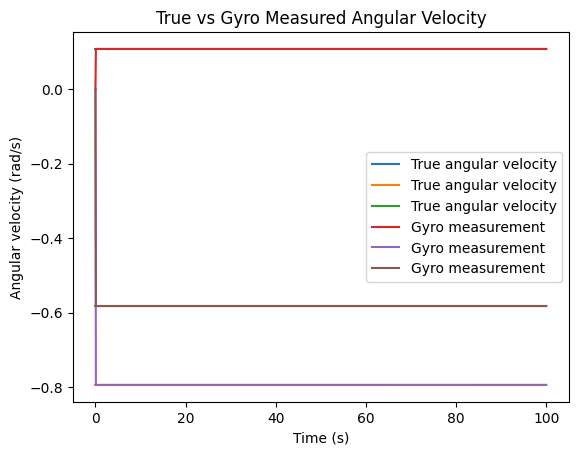

In [12]:
# plot the true vs measured angular velocity
import matplotlib.pyplot as plt
time = np.arange(n+1)*dt
plt.figure()
plt.plot(time, xk_true[:, 4:7], label='True angular velocity')
plt.plot(time, w_gyro, label='Gyro measurement')
plt.xlabel('Time (s)')
plt.ylabel('Angular velocity (rad/s)')
plt.legend()
plt.title('True vs Gyro Measured Angular Velocity')
plt.show()

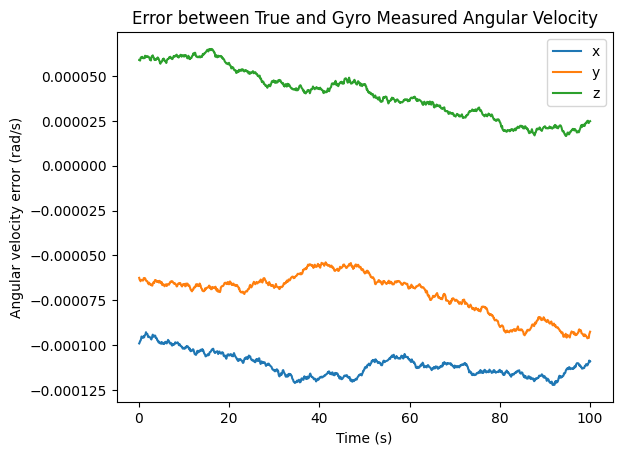

In [13]:
# Plot error between true and measured angular velocity
plt.figure()
plt.plot(time[1:], xk_true[1:, 4] - w_gyro[1:, 0], label='x')
plt.plot(time[1:], xk_true[1:, 5] - w_gyro[1:, 1], label='y')
plt.plot(time[1:], xk_true[1:, 6] - w_gyro[1:, 2], label='z')
plt.xlabel('Time (s)')
plt.ylabel('Angular velocity error (rad/s)')
plt.legend()
plt.title('Error between True and Gyro Measured Angular Velocity')
plt.show()